# Task 1 — Thematic Factor Discovery: Reasoning Model Analysis

Combines returns generation with statistical + LLM reasoning to identify which extracted factors
connect to post-filing stock performance across all 87 tickers.

**Model:** `deepseek-ai/DeepSeek-R1-Distill-Qwen-14B` via vLLM on ACCRE (DGX A100 40GB)

**Part A — Data Preparation (Steps 1–4, no GPU)**
1. Load scored factor JSONs for all tickers
2. Generate 21-day post-filing returns via `yfinance`
3. Merge factors with returns

**Part B — Analysis & Reasoning (Steps 5–9)**
4. Factor coverage analysis (cross-ticker)
5. Sentiment visualizations (aggregate + per-sector)
6. Factor evolution & statistical analysis (cross-ticker ICs)
7. Per-sector LLM reasoning (requires vLLM on ACCRE)
8. Display reasoning results

| | |
|---|---|
| **Input** | `output/factors_scored/{TICKER}/*_factors.json` (all tickers) |
| **Input** | Stock prices via `yfinance` (downloaded at runtime) |
| **Output** | `output/filing_returns.csv` — 21-day post-filing returns |
| **Output** | `output/reasoning_output.json` — per-sector LLM reasoning results |

> Steps 1–7 run locally (no GPU). Steps 8–9 require vLLM on ACCRE.

In [1]:
!pip install -r requirements.txt

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/lxml-5.3.1+computecanada-cp312-cp312-linux_x86_64.whl (from -r requirements.txt (line 2))
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/openai-2.26.0+computecanada-py3-none-any.whl (from -r requirements.txt (line 3))
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/pydantic-2.12.5+computecanada-py3-none-any.whl (from -r requirements.txt (line 4))
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/tqdm-4.67.3+computecanada-py3-none-any.whl (from -r requirements.txt (line 5))
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/seaborn-0.13.2+computecanada-py3-none-any.whl (from -r requirements.txt 

## Step 1: Imports & Configuration

In [2]:
import json
import logging
import re
import sys
import time
import threading
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import yfinance as yf
except ImportError:
    raise ImportError(
        "yfinance is required for returns generation. "
        "Install it with: pip install yfinance"
    )

try:
    from openai import OpenAI
except ImportError:
    OpenAI = None  # only needed for Steps 8-9

from pydantic import BaseModel
from tqdm.notebook import tqdm

# ── Paths ────────────────────────────────────────────────────────────────
_cwd = Path.cwd()

_search = _cwd
FILLINGS_ROOT = None
for _ in range(6):
    if (_search / "Data").is_dir():
        FILLINGS_ROOT = _search
        break
    _search = _search.parent

if FILLINGS_ROOT is None:
    raise FileNotFoundError(
        f"Could not find Data/ directory in any parent of {_cwd}. "
        "Make sure the notebook is inside the fillings/ project tree."
    )

FACTORS_SCORED_DIR = _cwd / "output" / "factors_scored"
RETURNS_CSV_PATH = _cwd / "output" / "filing_returns.csv"
REASONING_OUTPUT_PATH = _cwd / "output" / "reasoning_output.json"
TICKER_MAPPING_PATH = _cwd / "ticker_mapping.json"

# ── Load tickers & sector mapping from ticker_mapping.json ───────────────
with open(TICKER_MAPPING_PATH) as f:
    _ticker_map = json.load(f)

# Build sector → tickers and ticker → sector lookups
SECTOR_TICKERS = {}  # {"airlines": ["AAL", ...], "defense": [...], ...}
TICKER_SECTOR = {}   # {"AAL": "airlines", "BA": "defense", ...}
for sector, tickers in _ticker_map.items():
    SECTOR_TICKERS[sector] = sorted(tickers)
    for t in tickers:
        TICKER_SECTOR[t] = sector

ALL_TICKERS = sorted(TICKER_SECTOR.keys())

# ── Filter for testing (comment out these 2 lines to process all tickers) ──
# ALL_TICKERS = ["AAL"]
# SECTOR_TICKERS = {"airlines": ["AAL"]}

# ── LLM Constants (DeepSeek-R1 adapted) ─────────────────────────────────
BASE_URL = "http://127.0.0.1:8000/v1"
API_KEY = "local"
MODEL = "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B"
TEMPERATURE = 0.6  # DeepSeek-R1 recommendation
MAX_RETRIES = 5
RETRY_BASE_DELAY = 2.0
REQUEST_TIMEOUT = 600
MAX_IN_FLIGHT_LLM = 4

# ── Sentiment label → numeric score ──────────────────────────────────────
LABEL_TO_SCORE = {
    "very_negative": -2,
    "negative": -1,
    "neutral": 0,
    "positive": 1,
    "very_positive": 2,
}

# ── Pydantic models for LLM response validation ─────────────────────────
class ChangedFactor(BaseModel):
    key: str
    from_label: str = ""
    to_label: str = ""
    interpretation: str = ""

class PersistentTheme(BaseModel):
    key: str
    label: str = ""
    interpretation: str = ""

class EmergedDisappeared(BaseModel):
    key: str
    direction: str = ""
    interpretation: str = ""

class SectorReasoningResponse(BaseModel):
    key_trends: List[dict] = []
    sentiment_return_link: List[dict] = []
    sector_specific_factors: List[dict] = []
    overall_narrative: str = ""

class SynthesisPattern(BaseModel):
    pattern: str
    supporting_factors: List[str] = []
    direction: str = ""
    strength: str = ""
    explanation: str = ""

class PredictiveFactor(BaseModel):
    key: str
    rationale: str = ""
    confidence: str = "medium"

class SynthesisResponse(BaseModel):
    key_patterns: List[dict] = []
    most_predictive_factors: List[dict] = []
    overall_narrative: str = ""

# ── Logging ──────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)
log = logging.getLogger("task_1_5")

print(f"Fillings root:          {FILLINGS_ROOT}")
print(f"Scored factors dir:     {FACTORS_SCORED_DIR} (exists={FACTORS_SCORED_DIR.exists()})")
print(f"Returns CSV:            {RETURNS_CSV_PATH}")
print(f"Reasoning output:       {REASONING_OUTPUT_PATH}")
print(f"Ticker mapping:         {TICKER_MAPPING_PATH}")
print(f"Sectors:                {list(SECTOR_TICKERS.keys())}")
print(f"Total tickers:          {len(ALL_TICKERS)}")
print(f"Model:                  {MODEL}")
print(f"Temperature:            {TEMPERATURE}")

Fillings root:          /panfs/accrepfs.vampire/home/sivakur/asset/fillings
Scored factors dir:     /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_1/output/factors_scored (exists=True)
Returns CSV:            /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_1/output/filing_returns.csv
Reasoning output:       /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_1/output/reasoning_output.json
Ticker mapping:         /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_1/ticker_mapping.json
Sectors:                ['airlines', 'defense', 'industrial_equipment', 'general']
Total tickers:          86
Model:                  deepseek-ai/DeepSeek-R1-Distill-Qwen-14B
Temperature:            0.6


## Step 2: Load Scored Factor Data

Walk `output/factors_scored/{TICKER}/` and build a flat DataFrame of all factors with their sentiment labels.

In [3]:
rows = []
skipped_tickers = []
for ticker in ALL_TICKERS:
    ticker_dir = FACTORS_SCORED_DIR / ticker
    if not ticker_dir.exists():
        skipped_tickers.append(ticker)
        continue
    for fpath in sorted(ticker_dir.glob("*_factors.json")):
        with open(fpath) as f:
            data = json.load(f)
        filing_ticker = data["ticker"]
        form = data["form"]
        filing_date = data["filing_date"]
        for fac in data.get("factors", []):
            sentiment = fac.get("sentiment")
            if not isinstance(sentiment, dict) or not sentiment.get("label"):
                continue
            rows.append({
                "ticker": filing_ticker,
                "sector": TICKER_SECTOR.get(filing_ticker, "unknown"),
                "form": form,
                "filing_date": filing_date,
                "key": fac["key"],
                "category": fac["category"],
                "summary": fac["summary"],
                "label": sentiment["label"],
                "rationale": sentiment.get("rationale", ""),
                "confidence": sentiment.get("confidence", 0.5),
            })

factors_df = pd.DataFrame(rows)
factors_df["filing_date"] = pd.to_datetime(factors_df["filing_date"])
factors_df["score"] = factors_df["label"].map(LABEL_TO_SCORE)
factors_df = factors_df.sort_values(["ticker", "filing_date", "key"]).reset_index(drop=True)

print(f"Shape: {factors_df.shape}")
print(f"Unique tickers: {factors_df['ticker'].nunique()}")
print(f"Unique filings: {factors_df.groupby(['ticker', 'filing_date']).ngroups}")
print(f"Unique factor keys: {factors_df['key'].nunique()}")
if skipped_tickers:
    print(f"Tickers with no scored factors: {len(skipped_tickers)} — {skipped_tickers[:10]}{'...' if len(skipped_tickers) > 10 else ''}")
print(f"\nLabel distribution:")
label_order = ["very_negative", "negative", "neutral", "positive", "very_positive"]
print(factors_df["label"].value_counts().reindex(label_order).to_string())
print(f"\nSector distribution:")
print(factors_df.groupby("sector")["ticker"].nunique().to_string())
factors_df.head(10)

Shape: (67741, 11)
Unique tickers: 83
Unique filings: 2542
Unique factor keys: 430
Tickers with no scored factors: 3 — ['GNRC', 'LLL', 'RHI']

Label distribution:
label
very_negative     2772
negative         16636
neutral          22203
positive         24009
very_positive     2121

Sector distribution:
sector
airlines                 5
defense                 12
general                 33
industrial_equipment    33


,ticker,sector,form,filing_date,key,category,summary,label,rationale,confidence,score
0,AAL,airlines,10-K,2015-02-25,backlog_orders,demand_revenue,The company's order backlog is not explicitly ...,neutral,No explicit information about the backlog stat...,0.70,0
1,AAL,airlines,10-K,2015-02-25,capacity_load_yield,airlines_transport,The company is experiencing a mixed trend in c...,positive,Higher yields and stable load factors contribu...,0.75,1
2,AAL,airlines,10-K,2015-02-25,capacity_utilization,supply_chain_operations,The company is experiencing positive trends in...,positive,Positive trends in capacity utilization with n...,0.80,1
3,AAL,airlines,10-K,2015-02-25,capex_outlook,capital_allocation,The company is increasing its capital expendit...,positive,Increasing capital expenditures for modernizat...,0.70,1
4,AAL,airlines,10-K,2015-02-25,competitive_dynamics,competitive_position,The competitive environment in the airline ind...,negative,Intense competition from low-cost and internat...,0.80,-1
5,AAL,airlines,10-K,2015-02-25,cost_actions,cost_margins,The company has successfully implemented cost ...,positive,Successful cost reduction actions leading to m...,0.90,1
6,AAL,airlines,10-K,2015-02-25,debt_leverage,capital_allocation,The company has significant indebtedness which...,negative,"The company has significant debt, though it's ...",0.80,-1
7,AAL,airlines,10-K,2015-02-25,demand_trends,demand_revenue,Overall demand for air travel has been consist...,very_positive,Consistent strong demand driving sustained rev...,0.90,2
8,AAL,airlines,10-K,2015-02-25,economic_conditions,macro_external,Economic downturns negatively impact the compa...,negative,Economic downturns and external factors negati...,0.90,-1
9,AAL,airlines,10-K,2015-02-25,environmental_compliance,regulatory_legal,The company faces significant environmental co...,negative,Stricter environmental regulations leading to ...,0.80,-1


## Step 3: Generate Filing Returns

Download prices via `yfinance`, compute 21-trading-day returns and excess returns vs SPY.

In [4]:
# ── Resume: if filing_returns.csv already exists, load it ────────────────
if RETURNS_CSV_PATH.exists():
    returns_df = pd.read_csv(RETURNS_CSV_PATH, parse_dates=["filing_date"])
    # Check if we have returns for all tickers in our factor data
    existing_tickers = set(returns_df["ticker"].unique())
    needed_tickers = set(factors_df["ticker"].unique())
    missing_tickers = needed_tickers - existing_tickers
    if not missing_tickers:
        print(f"Loaded existing returns: {len(returns_df)} rows, {returns_df['ticker'].nunique()} tickers")
        print(f"Status: {returns_df['status'].value_counts().to_dict()}")
    else:
        print(f"Existing returns CSV missing {len(missing_tickers)} tickers — regenerating...")
        returns_df = None
else:
    returns_df = None
    missing_tickers = set(factors_df["ticker"].unique())

if returns_df is None:
    # Unique (ticker, filing_date) pairs from factor data
    filing_pairs = (
        factors_df[["ticker", "form", "filing_date"]]
        .drop_duplicates()
        .sort_values("filing_date")
        .reset_index(drop=True)
    )

    tickers_list = filing_pairs["ticker"].unique().tolist()
    download_tickers = sorted(set(tickers_list + ["SPY"]))

    min_date = filing_pairs["filing_date"].min() - timedelta(days=30)
    max_date = filing_pairs["filing_date"].max() + timedelta(days=60)

    print(f"Downloading prices for {len(download_tickers)} tickers from {min_date.date()} to {max_date.date()}...")

    # Download in batches of 50 to avoid yfinance timeouts
    BATCH_SIZE = 50
    all_prices = []
    for i in range(0, len(download_tickers), BATCH_SIZE):
        batch = download_tickers[i:i + BATCH_SIZE]
        print(f"  Batch {i//BATCH_SIZE + 1}: {len(batch)} tickers...")
        batch_prices = yf.download(
            batch,
            start=min_date.strftime("%Y-%m-%d"),
            end=max_date.strftime("%Y-%m-%d"),
            auto_adjust=True,
        )["Close"]
        if isinstance(batch_prices, pd.Series):
            batch_prices = batch_prices.to_frame(name=batch[0])
        all_prices.append(batch_prices)

    prices = pd.concat(all_prices, axis=1)
    # Remove duplicate columns (SPY might appear in multiple batches — it won't since we sort+dedup, but safety)
    prices = prices.loc[:, ~prices.columns.duplicated()]

    print(f"Price data shape: {prices.shape}, date range: {prices.index[0].date()} to {prices.index[-1].date()}")

    # ── Compute returns for each filing ─────────────────────────────────────
    returns_rows = []
    for _, row in tqdm(filing_pairs.iterrows(), total=len(filing_pairs), desc="Computing returns"):
        ticker = row["ticker"]
        form = row["form"]
        fdate = row["filing_date"]

        if ticker not in prices.columns:
            returns_rows.append({
                "ticker": ticker, "form": form, "filing_date": fdate,
                "ret_21d": np.nan, "ret_21d_spy": np.nan, "ret_21d_excess": np.nan,
                "status": "missing_price",
            })
            continue

        # Find filing date or next trading day in price index
        idx = prices.index.searchsorted(fdate)
        if idx >= len(prices.index):
            returns_rows.append({
                "ticker": ticker, "form": form, "filing_date": fdate,
                "ret_21d": np.nan, "ret_21d_spy": np.nan, "ret_21d_excess": np.nan,
                "status": "missing_price",
            })
            continue

        t0 = idx
        t21 = min(t0 + 21, len(prices.index) - 1)

        try:
            p0 = prices.iloc[t0][ticker]
            p21 = prices.iloc[t21][ticker]
            ret_21d = p21 / p0 - 1 if pd.notna(p0) and p0 != 0 else np.nan

            spy0 = prices.iloc[t0]["SPY"]
            spy21 = prices.iloc[t21]["SPY"]
            ret_21d_spy = spy21 / spy0 - 1 if pd.notna(spy0) and spy0 != 0 else np.nan

            ret_21d_excess = ret_21d - ret_21d_spy if pd.notna(ret_21d) and pd.notna(ret_21d_spy) else np.nan
            status = "ok" if pd.notna(ret_21d) else "missing_price"
        except (KeyError, IndexError):
            ret_21d = ret_21d_spy = ret_21d_excess = np.nan
            status = "missing_price"

        returns_rows.append({
            "ticker": ticker, "form": form, "filing_date": fdate,
            "ret_21d": ret_21d, "ret_21d_spy": ret_21d_spy,
            "ret_21d_excess": ret_21d_excess, "status": status,
        })

    returns_df = pd.DataFrame(returns_rows)
    returns_df.to_csv(RETURNS_CSV_PATH, index=False)
    print(f"\nSaved {len(returns_df)} rows to {RETURNS_CSV_PATH}")

print(f"\nReturns summary:")
print(f"  Total filings: {len(returns_df)}")
print(f"  OK: {(returns_df['status'] == 'ok').sum()}")
print(f"  Missing: {(returns_df['status'] == 'missing_price').sum()}")
print(f"  Mean 21d excess return: {returns_df['ret_21d_excess'].mean():.4f}")
returns_df.head(10)

Existing returns CSV missing 82 tickers — regenerating...
  Batch 1: 50 tickers...


[*********             18%                       ]  9 of 50 completed

19:27:13 | ERROR   | $KSU: possibly delisted; no timezone found


[*********************100%***********************]  50 of 50 completed

19:27:14 | ERROR   | 
1 Failed download:
19:27:14 | ERROR   | ['KSU']: possibly delisted; no timezone found


...

19:27:16 | ERROR   | 
2 Failed downloads:
19:27:16 | ERROR   | ['RTN', 'NLSN']: possibly delisted; no timezone found


Price data shape: (2676, 84), date range: 2014-12-10 to 2025-08-01


Computing returns:   0%|          | 0/2542 [00:00<?, ?it/s]


Saved 2542 rows to /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_1/output/filing_returns.csv

Returns summary:
  Total filings: 2542
  OK: 2441
  Missing: 101
  Mean 21d excess return: 0.0047


,ticker,form,filing_date,ret_21d,ret_21d_spy,ret_21d_excess,status
0,AYI,10-Q,2015-01-09,0.060464,0.012534,0.047931,ok
1,CTAS,10-Q,2015-01-09,0.044865,0.012534,0.032331,ok
2,URI,10-K,2015-01-21,0.096163,0.040182,0.055981,ok
3,JCI,10-Q,2015-01-30,0.056604,0.058511,-0.001907,ok
4,KSU,10-K,2015-01-30,NaN,0.058511,NaN,missing_price
5,J,10-Q,2015-02-02,0.098620,0.041155,0.057465,ok
6,NOC,10-K,2015-02-02,0.034068,0.041155,-0.007087,ok
7,ROK,10-Q,2015-02-05,-0.000649,0.010867,-0.011516,ok
8,FAST,10-K,2015-02-05,-0.028293,0.010867,-0.039161,ok
9,LUV,10-K,2015-02-06,-0.025864,-0.002773,-0.023091,ok


## Step 4: Merge Factors with Returns

In [5]:
# Reload from CSV to ensure consistency
returns = pd.read_csv(RETURNS_CSV_PATH, parse_dates=["filing_date"])

df = factors_df.merge(
    returns[["ticker", "filing_date", "ret_21d", "ret_21d_excess"]],
    on=["ticker", "filing_date"],
    how="left",
)

print(f"Merged shape: {df.shape}")
print(f"Factors with returns: {df['ret_21d_excess'].notna().sum()} / {len(df)}")

# Filing-level summary
filing_summary = (
    df.groupby(["ticker", "sector", "filing_date", "form"])
    .agg(
        num_factors=("key", "count"),
        avg_score=("score", "mean"),
        ret_21d_excess=("ret_21d_excess", "first"),
    )
    .reset_index()
    .sort_values("filing_date")
)
print(f"\nFiling-level summary: {len(filing_summary)} filings across {filing_summary['sector'].nunique()} sectors")
print(f"\nPer-sector filing counts:")
print(filing_summary.groupby("sector")["ticker"].nunique().to_string())
filing_summary.head(10)

Merged shape: (67741, 13)
Factors with returns: 65494 / 67741

Filing-level summary: 2542 filings across 4 sectors

Per-sector filing counts:
sector
airlines                 5
defense                 12
general                 33
industrial_equipment    33


,ticker,sector,filing_date,form,num_factors,avg_score,ret_21d_excess
284,AYI,industrial_equipment,2015-01-09,10-Q,11,1.090909,0.047931
653,CTAS,general,2015-01-09,10-Q,10,1.100000,0.032331
2441,URI,general,2015-01-21,10-K,8,1.250000,0.055981
1506,JCI,industrial_equipment,2015-01-30,10-Q,16,0.125000,-0.001907
1522,KSU,general,2015-01-30,10-K,47,-0.042553,NaN
1461,J,general,2015-02-02,10-Q,11,0.272727,0.057465
1895,NOC,defense,2015-02-02,10-K,30,-0.300000,-0.007087
2179,ROK,industrial_equipment,2015-02-05,10-Q,14,0.928571,-0.011516
928,FAST,general,2015-02-05,10-K,15,-0.400000,-0.039161
1705,LUV,airlines,2015-02-06,10-K,47,0.489362,-0.023091


## Step 5: Factor Coverage Analysis

Identify which factors appear consistently across filings vs. sporadically.

In [6]:
n_filings = df.groupby(["ticker", "filing_date"]).ngroups
n_tickers = df["ticker"].nunique()

# Factor coverage: how many filings does each factor key appear in?
factor_counts = df.groupby("key")["filing_date"].nunique().sort_values(ascending=False)

# Thresholds scale with dataset size — "consistent" means ≥10% of filings
consistency_threshold = max(3, int(n_filings * 0.10))
consistent = factor_counts[factor_counts >= consistency_threshold]
sporadic = factor_counts[factor_counts < consistency_threshold]
unique_to_one = factor_counts[factor_counts == 1]

print(f"Total filings: {n_filings} across {n_tickers} tickers")
print(f"Total unique factor keys: {len(factor_counts)}")
print(f"Consistency threshold: {consistency_threshold}+ filings (10% of {n_filings})")
print(f"Consistent factors: {len(consistent)}")
print(f"Sporadic factors: {len(sporadic)}")
print(f"Unique to one filing: {len(unique_to_one)}")

# Consistent factors by sector coverage
print(f"\n{'='*60}")
print(f"TOP 30 CONSISTENT FACTORS:")
key_to_cat = df.drop_duplicates("key").set_index("key")["category"]
for key, count in consistent.head(30).items():
    cat = key_to_cat.get(key, "?")
    # How many sectors does this factor appear in?
    sectors_present = df[df["key"] == key]["sector"].nunique()
    print(f"  [{cat}] {key} — {count}/{n_filings} filings, {sectors_present}/{len(SECTOR_TICKERS)} sectors")

# Per-sector factor coverage
print(f"\n{'='*60}")
print("FACTORS PER SECTOR:")
for sector in sorted(SECTOR_TICKERS.keys()):
    sector_df = df[df["sector"] == sector]
    if len(sector_df) == 0:
        continue
    sector_keys = sector_df["key"].nunique()
    sector_filings = sector_df.groupby(["ticker", "filing_date"]).ngroups
    print(f"  {sector}: {sector_keys} unique factors across {sector_filings} filings")

Total filings: 2542 across 83 tickers
Total unique factor keys: 430
Consistency threshold: 254+ filings (10% of 2542)
Consistent factors: 48
Sporadic factors: 382
Unique to one filing: 249

TOP 30 CONSISTENT FACTORS:
  [cost_margins] margin_trajectory — 926/2542 filings, 4/4 sectors
  [demand_revenue] demand_trends — 915/2542 filings, 4/4 sectors
  [demand_revenue] organic_growth — 913/2542 filings, 4/4 sectors
  [demand_revenue] volume_trends — 889/2542 filings, 4/4 sectors
  [demand_revenue] pricing_power — 871/2542 filings, 4/4 sectors
  [outlook_guidance] key_sensitivities — 864/2542 filings, 4/4 sectors
  [capital_allocation] free_cash_flow — 858/2542 filings, 4/4 sectors
  [capital_allocation] shareholder_returns — 857/2542 filings, 4/4 sectors
  [cost_margins] input_costs — 852/2542 filings, 4/4 sectors
  [capital_allocation] debt_leverage — 851/2542 filings, 4/4 sectors
  [capital_allocation] capex_outlook — 845/2542 filings, 4/4 sectors
  [cost_margins] cost_actions — 843/2542

## Step 6: Sentiment Visualizations

Aggregate views across all tickers:
1. **Overall Sentiment Distribution** — label counts across all filings
2. **Sector-Level Sentiment Heatmap** — average score by sector and category
3. **Sentiment vs Returns by Sector** — scatter of filing-level avg sentiment vs excess return

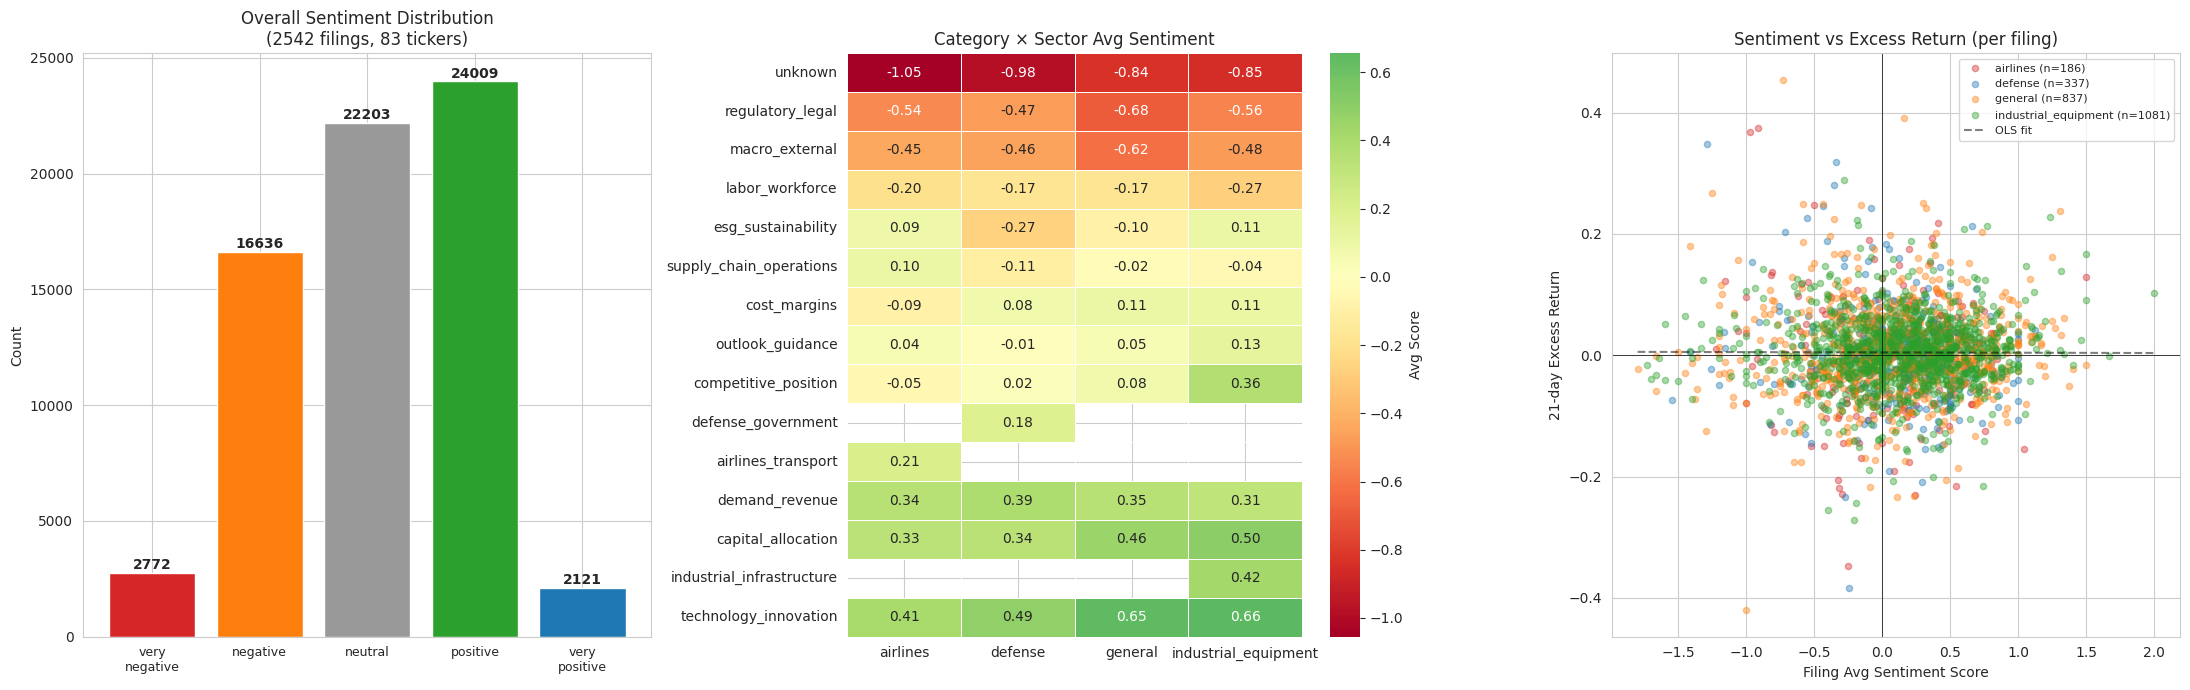

In [7]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

label_order = ["very_negative", "negative", "neutral", "positive", "very_positive"]
label_colors = ["#d62728", "#ff7f0e", "#999999", "#2ca02c", "#1f77b4"]

# ── Viz 1: Overall Sentiment Distribution ────────────────────────────────
ax1 = axes[0]
label_counts = df["label"].value_counts().reindex(label_order, fill_value=0)
bars = ax1.bar(range(len(label_order)), label_counts.values, color=label_colors)
ax1.set_xticks(range(len(label_order)))
ax1.set_xticklabels([l.replace("_", "\n") for l in label_order], fontsize=9)
ax1.set_ylabel("Count")
ax1.set_title(f"Overall Sentiment Distribution\n({n_filings} filings, {n_tickers} tickers)")
for bar, val in zip(bars, label_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Viz 2: Sector × Category Sentiment Heatmap ──────────────────────────
ax2 = axes[1]
sector_cat_pivot = df.pivot_table(
    values="score", index="category", columns="sector", aggfunc="mean",
)
# Sort categories by overall mean score
sector_cat_pivot = sector_cat_pivot.loc[sector_cat_pivot.mean(axis=1).sort_values().index]

sns.heatmap(
    sector_cat_pivot, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
    linewidths=0.5, ax=ax2, cbar_kws={"label": "Avg Score"},
)
ax2.set_title("Category × Sector Avg Sentiment")
ax2.set_xlabel("")
ax2.set_ylabel("")

# ── Viz 3: Sentiment vs Returns by Sector ────────────────────────────────
ax3 = axes[2]
fs_valid = filing_summary.dropna(subset=["ret_21d_excess"]).copy()

sector_colors = {"airlines": "#d62728", "defense": "#1f77b4", "industrial_equipment": "#2ca02c", "general": "#ff7f0e"}
for sector, sdf in fs_valid.groupby("sector"):
    color = sector_colors.get(sector, "#999999")
    ax3.scatter(sdf["avg_score"], sdf["ret_21d_excess"], alpha=0.4, s=20,
                color=color, label=f"{sector} (n={len(sdf)})")

# Overall regression line
if len(fs_valid) >= 10:
    z = np.polyfit(fs_valid["avg_score"], fs_valid["ret_21d_excess"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(fs_valid["avg_score"].min(), fs_valid["avg_score"].max(), 50)
    ax3.plot(x_range, p(x_range), "--", color="black", alpha=0.5, linewidth=1.5, label="OLS fit")

ax3.set_xlabel("Filing Avg Sentiment Score")
ax3.set_ylabel("21-day Excess Return")
ax3.set_title("Sentiment vs Excess Return (per filing)")
ax3.axhline(0, color="black", linewidth=0.5)
ax3.axvline(0, color="black", linewidth=0.5)
ax3.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

## Step 7: Cross-Ticker Statistical Analysis

With ~87 tickers and hundreds of filings, we now have real statistical power:
- **Filing-level Spearman**: avg sentiment score vs 21d excess return across all filings
- **Factor-level IC**: cross-sectional Spearman for each factor (across all tickers/dates)
- **Sector-level correlation**: per-sector sentiment-return relationship
- **Per-sector scatter**: visualize relationship by sector

FILING-LEVEL CORRELATION (ALL TICKERS)
Spearman(avg_score, ret_21d_excess): rho=0.0135, p=0.5043  (N=2441 filings)

PER-SECTOR FILING-LEVEL CORRELATION
  airlines: rho=0.0094, p=0.8982 (N=186)
  defense: rho=-0.1464, p=0.0071 (N=337)
  general: rho=0.0458, p=0.1858 (N=837)
  industrial_equipment: rho=0.0277, p=0.3630 (N=1081)

FACTOR-LEVEL IC (top 30 by |IC|, threshold=254+ filings)
                     key                  category    n  n_tickers      IC  p_value
    interest_rate_impact            macro_external 1195         76  0.0999   0.0005
            new_products     technology_innovation  725         65 -0.0796   0.0320
           trade_tariffs          regulatory_legal  717         65  0.0594   0.1121
           rd_investment     technology_innovation  782         60 -0.0566   0.1136
             fx_exposure            macro_external 1317         72 -0.0520   0.0594
 headcount_restructuring           labor_workforce  810         72 -0.0503   0.1525
           capex_outlook  

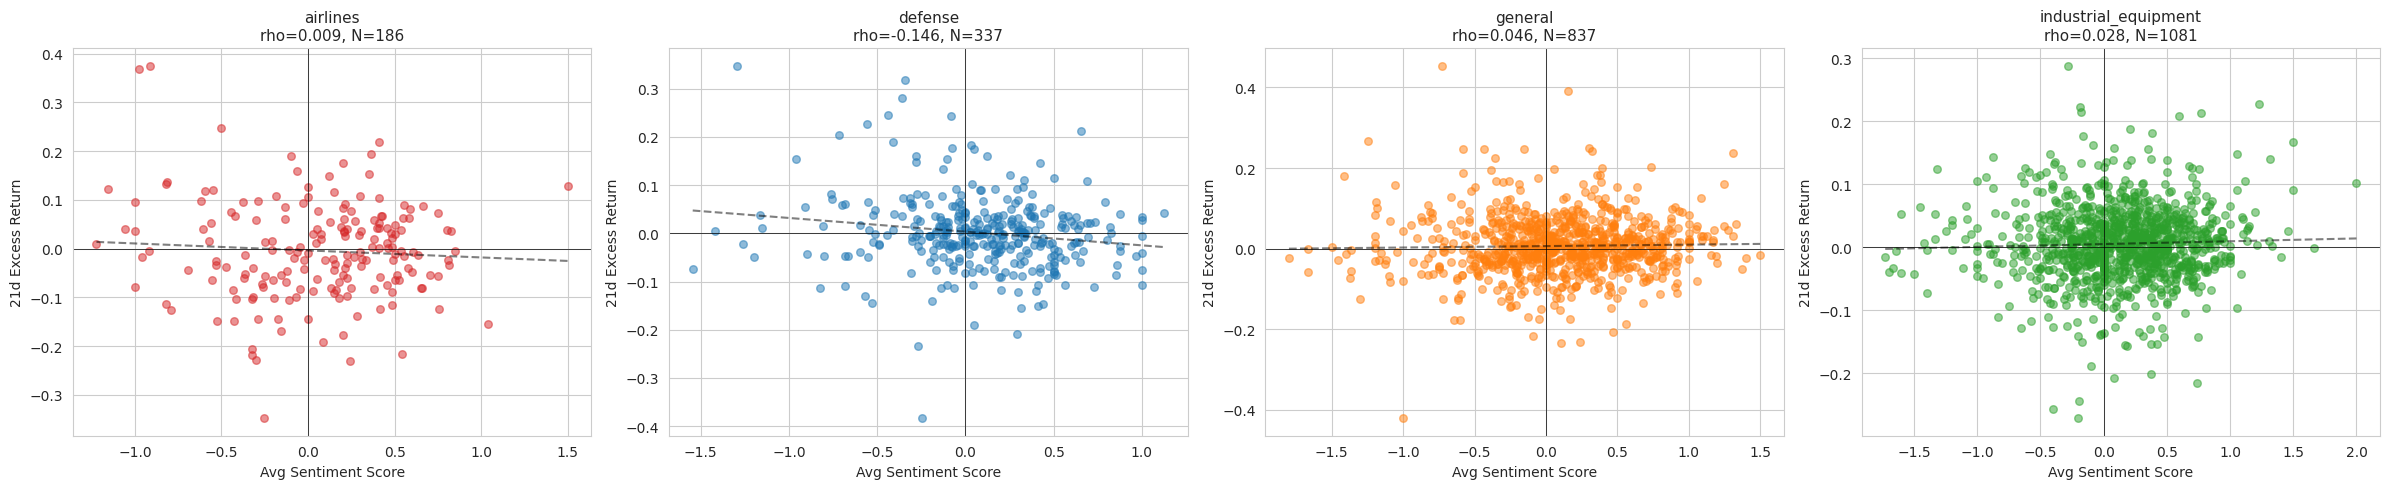

In [8]:
from scipy.stats import spearmanr

consistent_keys = factor_counts[factor_counts >= consistency_threshold].index.tolist()

# ── Filing-level correlation (all tickers) ───────────────────────────────
print("="*60)
print("FILING-LEVEL CORRELATION (ALL TICKERS)")
print("="*60)

fs = filing_summary.dropna(subset=["ret_21d_excess"]).copy()
if len(fs) >= 10:
    corr, pval = spearmanr(fs["avg_score"], fs["ret_21d_excess"])
    print(f"Spearman(avg_score, ret_21d_excess): rho={corr:.4f}, p={pval:.4f}  (N={len(fs)} filings)")
else:
    print(f"Only {len(fs)} filings with returns — need more data")

# ── Per-sector correlation ───────────────────────────────────────────────
print(f"\n{'='*60}")
print("PER-SECTOR FILING-LEVEL CORRELATION")
print("="*60)

sector_corr_rows = []
for sector, sdf in fs.groupby("sector"):
    if len(sdf) >= 5:
        sc, sp = spearmanr(sdf["avg_score"], sdf["ret_21d_excess"])
        sector_corr_rows.append({"sector": sector, "n_filings": len(sdf), "spearman_rho": sc, "p_value": sp})
        print(f"  {sector}: rho={sc:.4f}, p={sp:.4f} (N={len(sdf)})")
    else:
        sector_corr_rows.append({"sector": sector, "n_filings": len(sdf), "spearman_rho": np.nan, "p_value": np.nan})
        print(f"  {sector}: N={len(sdf)} — too few filings")

sector_corr_df = pd.DataFrame(sector_corr_rows)

# ── Factor-level cross-sectional IC ──────────────────────────────────────
print(f"\n{'='*60}")
print(f"FACTOR-LEVEL IC (top 30 by |IC|, threshold={consistency_threshold}+ filings)")
print("="*60)

ic_rows = []
for key in consistent_keys:
    fac_data = df[df["key"] == key].dropna(subset=["ret_21d_excess"]).copy()
    if len(fac_data) >= 10 and fac_data["score"].nunique() > 1:
        ic, ic_p = spearmanr(fac_data["score"], fac_data["ret_21d_excess"])
        ic_rows.append({
            "key": key,
            "category": fac_data["category"].iloc[0],
            "n": len(fac_data),
            "n_tickers": fac_data["ticker"].nunique(),
            "IC": ic,
            "p_value": ic_p,
        })

ic_df = pd.DataFrame(ic_rows).sort_values("IC", key=abs, ascending=False)
print(ic_df.head(30).to_string(index=False, float_format="%.4f"))

# ── Per-sector scatter plots ─────────────────────────────────────────────
n_sectors = len([s for s in SECTOR_TICKERS if len(fs[fs["sector"] == s]) >= 5])
if n_sectors > 0:
    fig, axes = plt.subplots(1, n_sectors, figsize=(6 * n_sectors, 5), squeeze=False)
    axes = axes.flatten()
    plot_idx = 0
    for sector in sorted(SECTOR_TICKERS.keys()):
        sdf = fs[fs["sector"] == sector]
        if len(sdf) < 5:
            continue
        ax = axes[plot_idx]
        ax.scatter(sdf["avg_score"], sdf["ret_21d_excess"], alpha=0.5, s=30,
                   color=sector_colors.get(sector, "#999999"))
        if len(sdf) >= 5:
            z = np.polyfit(sdf["avg_score"], sdf["ret_21d_excess"], 1)
            p = np.poly1d(z)
            x_range = np.linspace(sdf["avg_score"].min(), sdf["avg_score"].max(), 50)
            ax.plot(x_range, p(x_range), "--", color="black", alpha=0.5)
            sc_row = sector_corr_df[sector_corr_df["sector"] == sector]
            if len(sc_row) > 0 and pd.notna(sc_row.iloc[0]["spearman_rho"]):
                rho = sc_row.iloc[0]["spearman_rho"]
                ax.set_title(f"{sector}\nrho={rho:.3f}, N={len(sdf)}", fontsize=11)
            else:
                ax.set_title(f"{sector} (N={len(sdf)})", fontsize=11)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_xlabel("Avg Sentiment Score")
        ax.set_ylabel("21d Excess Return")
        plot_idx += 1

    plt.tight_layout()
    plt.show()

## Step 7b: Factor Significance on Stock Movements

Cross-ticker significance analysis with real statistical power:
1. **Factor-level**: IC, directional hit rate, mean return by sentiment polarity
2. **Category-level**: IC across all tickers
3. **Composite significance ranking** combining coverage, IC, and directional consistency

FACTOR SIGNIFICANCE ON STOCK MOVEMENTS (top 30)
                    key                  category  coverage  n_tickers  mean_score  score_range  directional_hit_rate      IC  IC_pvalue  significance
   interest_rate_impact            macro_external      1195         76     -0.2435            4                0.5441  0.0999     0.0005        0.0685
    capacity_load_yield        airlines_transport       154          5      0.0844            4                0.3636 -0.2712     0.0007        0.0534
           new_products     technology_innovation       725         65      0.7310            4                0.4909 -0.0796     0.0320        0.0425
        reputation_risk                   unknown        12          5     -1.3333            1                0.5833  0.5121     0.0887        0.0422
          capex_outlook        capital_allocation      1676         76      0.4714            4                0.5092 -0.0488     0.0457        0.0396
            fx_exposure            macro_exter

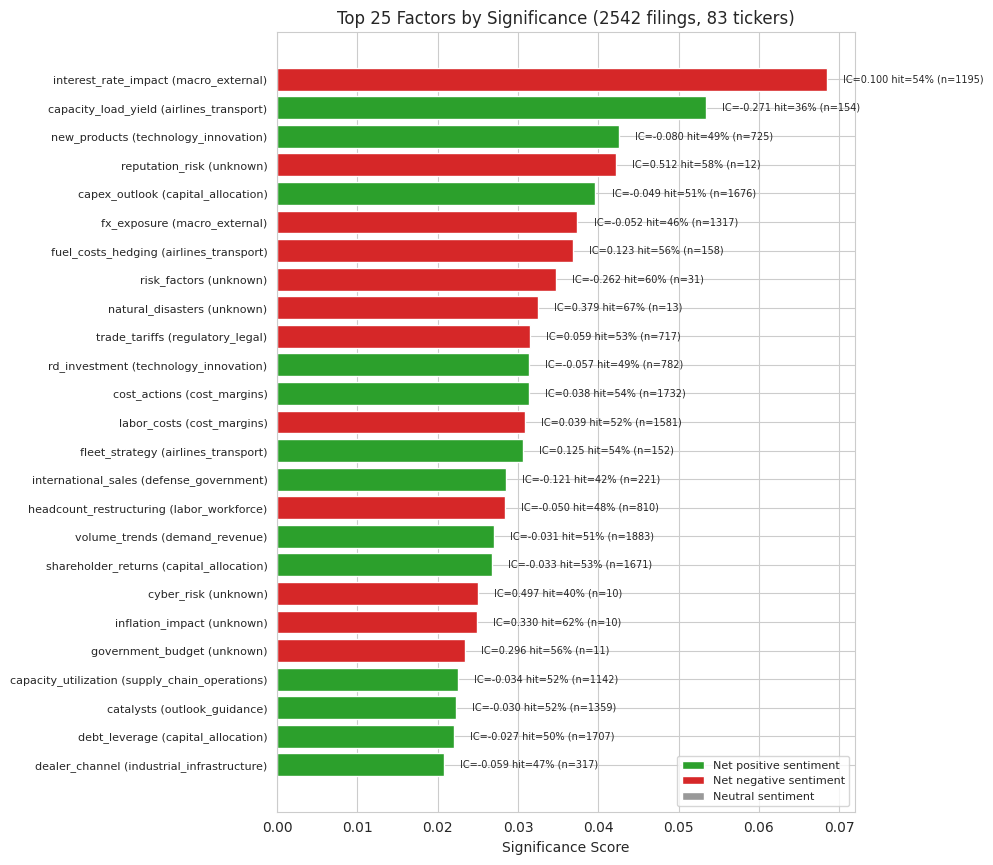

In [9]:
# ── Factor-level significance ────────────────────────────────────────
sig_rows = []
for key, grp in df.groupby("key"):
    grp_valid = grp.dropna(subset=["ret_21d_excess"])
    if len(grp_valid) < 5:
        continue

    scores = grp_valid["score"]
    rets = grp_valid["ret_21d_excess"]

    pos_mask = scores > 0
    neg_mask = scores < 0

    # Directional hit rate
    nonzero = scores != 0
    hits = ((scores[nonzero] > 0) == (rets[nonzero] > 0)).mean() if nonzero.sum() > 0 else np.nan

    # IC
    ic_val = np.nan
    ic_p = np.nan
    if len(grp_valid) >= 10 and scores.nunique() > 1:
        ic_val, ic_p = spearmanr(scores, rets)

    sig_rows.append({
        "key": key,
        "category": grp_valid["category"].iloc[0],
        "coverage": len(grp_valid),
        "n_tickers": grp_valid["ticker"].nunique(),
        "mean_score": scores.mean(),
        "score_range": scores.max() - scores.min(),
        "mean_ret_positive": rets[pos_mask].mean() if pos_mask.sum() > 0 else np.nan,
        "mean_ret_negative": rets[neg_mask].mean() if neg_mask.sum() > 0 else np.nan,
        "directional_hit_rate": hits,
        "IC": ic_val,
        "IC_pvalue": ic_p,
    })

significance_df = pd.DataFrame(sig_rows)

# Composite significance score:
#   |IC| * sqrt(coverage/n_filings) * (1.2 if hit_rate > 0.55 else 0.8 if hit_rate < 0.45 else 1.0)
significance_df["significance"] = significance_df.apply(
    lambda r: (
        abs(r["IC"]) * np.sqrt(r["coverage"] / n_filings) *
        (1.2 if r["directional_hit_rate"] > 0.55 else 0.8 if r["directional_hit_rate"] < 0.45 else 1.0)
        if pd.notna(r["IC"])
        else abs(r["mean_score"]) * r["coverage"] / (n_filings * 5)
    ),
    axis=1,
)

significance_df = significance_df.sort_values("significance", ascending=False).reset_index(drop=True)

print("="*70)
print(f"FACTOR SIGNIFICANCE ON STOCK MOVEMENTS (top 30)")
print("="*70)
display_cols = ["key", "category", "coverage", "n_tickers", "mean_score", "score_range",
                "directional_hit_rate", "IC", "IC_pvalue", "significance"]
print(significance_df[display_cols].head(30).to_string(index=False, float_format="%.4f"))

# ── Category-level significance ──────────────────────────────────────
print(f"\n{'='*70}")
print("CATEGORY-LEVEL SIGNIFICANCE")
print("="*70)

cat_sig_rows = []
for cat, cgrp in df.groupby("category"):
    cat_filing = cgrp.groupby(["ticker", "filing_date"]).agg(
        avg_score=("score", "mean"),
        ret_21d_excess=("ret_21d_excess", "first"),
    ).dropna()
    if len(cat_filing) < 10:
        cat_sig_rows.append({"category": cat, "n_filings": len(cat_filing),
                             "IC": np.nan, "IC_pvalue": np.nan,
                             "mean_score": cat_filing["avg_score"].mean() if len(cat_filing) > 0 else np.nan})
        continue
    ic_val, ic_p = spearmanr(cat_filing["avg_score"], cat_filing["ret_21d_excess"])
    cat_sig_rows.append({"category": cat, "n_filings": len(cat_filing),
                         "IC": ic_val, "IC_pvalue": ic_p,
                         "mean_score": cat_filing["avg_score"].mean()})

cat_sig_df = pd.DataFrame(cat_sig_rows).sort_values("IC", key=abs, ascending=False)
print(cat_sig_df.to_string(index=False, float_format="%.4f"))

# ── Visualization: top factors by significance ───────────────────────
top_n = min(25, len(significance_df))
top = significance_df.head(top_n).copy()

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
colors = ["#2ca02c" if s > 0 else "#d62728" if s < 0 else "#999999" for s in top["mean_score"]]
ax.barh(range(top_n), top["significance"], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"{r['key']} ({r['category']})" for _, r in top.iterrows()], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Significance Score")
ax.set_title(f"Top {top_n} Factors by Significance ({n_filings} filings, {n_tickers} tickers)")

for i, (_, r) in enumerate(top.iterrows()):
    ic_str = f"IC={r['IC']:.3f}" if pd.notna(r["IC"]) else "IC=n/a"
    hr_str = f"hit={r['directional_hit_rate']:.0%}" if pd.notna(r["directional_hit_rate"]) else ""
    ax.text(r["significance"] + 0.002, i, f"{ic_str} {hr_str} (n={r['coverage']})", va="center", fontsize=7)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ca02c", label="Net positive sentiment"),
    Patch(facecolor="#d62728", label="Net negative sentiment"),
    Patch(facecolor="#999999", label="Neutral sentiment"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## Step 8: LLM Client & Reasoning Prompts

DeepSeek-R1 adapted LLM client with `response_format={"type": "json_object"}` and `<think>` tag stripping.

**Per-sector reasoning** (not per-ticker pairwise):
1. For each sector, aggregate the top statistically significant factors
2. One LLM reasoning call per sector identifying factor-return patterns
3. One cross-sector synthesis call

> **Requires vLLM on ACCRE.** Steps 8-9 will skip gracefully if the server is unreachable.

In [10]:
# ── LLM Client (DeepSeek-R1 adapted) ─────────────────────────────────────
_semaphore = threading.BoundedSemaphore(MAX_IN_FLIGHT_LLM)

REASONING_MAX_TOKENS = 16384


def call_llm(
    client: "OpenAI",
    system_prompt: str,
    user_prompt: str,
    temperature: float = TEMPERATURE,
    max_tokens: int = REASONING_MAX_TOKENS,
    force_json: bool = True,
) -> Optional[str]:
    """Call the LLM with retry logic, concurrency control, and response_format."""
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            kwargs = dict(
                model=MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                temperature=temperature,
                max_tokens=max_tokens,
                timeout=REQUEST_TIMEOUT,
            )
            if force_json:
                kwargs["response_format"] = {"type": "json_object"}
            with _semaphore:
                response = client.chat.completions.create(**kwargs)
            return response.choices[0].message.content
        except Exception as e:
            delay = RETRY_BASE_DELAY * (2 ** (attempt - 1))
            log.warning(f"  LLM attempt {attempt}/{MAX_RETRIES} failed: {e}. Retrying in {delay}s...")
            if attempt < MAX_RETRIES:
                time.sleep(delay)
            else:
                log.error(f"  LLM call failed after {MAX_RETRIES} attempts: {e}")
                return None


def parse_json_response(content: str) -> Optional[Any]:
    """Parse JSON from LLM response, handling <think> blocks and markdown code blocks."""
    content = content.strip()

    # Strip DeepSeek-R1 <think>...</think> reasoning blocks (closed)
    content = re.sub(r"<think>.*?</think>", "", content, flags=re.DOTALL).strip()

    # Strip unclosed <think> blocks (truncated response)
    if "<think>" in content:
        content = re.sub(r"<think>.*", "", content, flags=re.DOTALL).strip()

    if content.startswith("```"):
        content = content.split("\n", 1)[1] if "\n" in content else content[3:]
        if content.endswith("```"):
            content = content[:-3]
        content = content.strip()
    try:
        return json.loads(content)
    except json.JSONDecodeError:
        pass
    start_obj = content.find("{")
    start_arr = content.find("[")
    if start_obj == -1 and start_arr == -1:
        log.warning(f"  No JSON found in response ({len(content)} chars)")
        return None
    if start_arr != -1 and (start_obj == -1 or start_arr < start_obj):
        start, end = start_arr, content.rfind("]")
    else:
        start, end = start_obj, content.rfind("}")
    if end == -1 or end <= start:
        return None
    try:
        return json.loads(content[start:end + 1])
    except json.JSONDecodeError as e:
        log.warning(f"  JSON parse error: {e}")
        return None


def call_llm_json(
    client: "OpenAI",
    system_prompt: str,
    user_prompt: str,
    temperature: float = TEMPERATURE,
    max_tokens: int = REASONING_MAX_TOKENS,
    response_model: Optional[type] = None,
) -> Optional[Any]:
    """Call the LLM, parse JSON, optionally validate with Pydantic."""
    content = call_llm(client, system_prompt, user_prompt, temperature, max_tokens)
    if content is None:
        return None
    result = parse_json_response(content)
    if result is None:
        return None
    if response_model is not None:
        try:
            validated = response_model(**result)
            return validated.model_dump()
        except Exception as e:
            log.warning(f"  Pydantic validation failed: {e}")
            return result  # return raw dict as fallback
    return result


# ── Client creation + health check ───────────────────────────────────────
llm_available = False
if OpenAI is not None:
    client = OpenAI(base_url=BASE_URL, api_key=API_KEY)
    try:
        models = client.models.list()
        available = [m.id for m in models.data]
        print(f"vLLM is reachable. Available models: {available}")
        if MODEL not in available:
            print(f"WARNING: {MODEL} not in available models!")
        llm_available = True
    except Exception as e:
        print(f"WARNING: vLLM not reachable ({e}).")
        print("Steps 8-9 (LLM reasoning) will be skipped.")
        print("Steps 1-7 (data + statistical analysis) still work without GPU.")
else:
    print("openai package not installed. Steps 8-9 will be skipped.")

# ── Reasoning Prompts ────────────────────────────────────────────────────
REASONING_SYSTEM_PROMPT = "You are a financial analyst specializing in SEC filing analysis. Always respond with valid JSON only."

SECTOR_REASONING_SCHEMA = """\
You MUST respond with ONLY a JSON object in this exact structure (no other text):
{
  "key_trends": [
    {"factor": "<factor_key>", "trend": "<describe the trend across filings>", "sectors_affected": "<which tickers or all>"}
  ],
  "sentiment_return_link": [
    {"factor": "<factor_key>", "IC": <number>, "hit_rate": <number>, "interpretation": "<1-2 sentences explaining why this factor's sentiment predicts returns>"}
  ],
  "sector_specific_factors": [
    {"factor": "<factor_key>", "why_sector_specific": "<1-2 sentences>", "investment_signal": "positive or negative or mixed"}
  ],
  "overall_narrative": "<3-5 sentences summarizing the key factor-return patterns in this sector>"
}"""

CROSS_SECTOR_SYNTHESIS_SCHEMA = """\
You MUST respond with ONLY a JSON object in this exact structure (no other text):
{
  "key_patterns": [
    {
      "pattern": "<describe the cross-sector pattern>",
      "supporting_factors": ["<factor_key_1>", "<factor_key_2>"],
      "sectors": ["<sector_1>", "<sector_2>"],
      "direction": "positive or negative or mixed",
      "strength": "strong or moderate or weak",
      "explanation": "<2-3 sentences>"
    }
  ],
  "most_predictive_factors": [
    {"key": "<factor_key>", "sectors": ["<sector>"], "rationale": "<1-2 sentences>", "confidence": "high or medium or low"}
  ],
  "sector_comparison": [
    {"observation": "<1-2 sentences comparing how sectors differ>"}
  ],
  "overall_narrative": "<3-5 sentences>"
}"""

print(f"Reasoning prompts loaded. Max tokens: {REASONING_MAX_TOKENS}")

19:27:21 | INFO    | HTTP Request: GET http://127.0.0.1:8000/v1/models "HTTP/1.1 200 OK"
vLLM is reachable. Available models: ['deepseek-ai/DeepSeek-R1-Distill-Qwen-14B']
Reasoning prompts loaded. Max tokens: 16384


## Step 9: Run Per-Sector LLM Reasoning

For each sector:
1. Aggregate top factors (by significance) with their IC, hit rate, and sentiment trends
2. One LLM call per sector to reason about factor-return patterns
3. One cross-sector synthesis call to identify universal vs sector-specific patterns

**4 sector calls + 1 synthesis = 5 LLM calls total** (much more efficient than per-ticker pairwise)

Results saved to `output/reasoning_output.json`.

In [11]:
if not llm_available:
    print("Skipping LLM reasoning — vLLM server not available.")
    print("Run this notebook on ACCRE with vLLM to execute Steps 8-9.")
else:
    TOP_FACTORS_PER_SECTOR = 20  # top factors by significance to include in prompt

    def _build_sector_prompt(sector: str, sector_df: pd.DataFrame) -> str:
        """Build a reasoning prompt for one sector with its top factors and stats."""
        sector_tickers = sorted(sector_df["ticker"].unique())
        sector_filings = sector_df.groupby(["ticker", "filing_date"]).ngroups

        # Get top factors for this sector by significance
        sector_sig = significance_df[
            significance_df["key"].isin(sector_df["key"].unique())
        ].head(TOP_FACTORS_PER_SECTOR)

        # Sentiment distribution for this sector
        label_dist = sector_df["label"].value_counts().reindex(label_order, fill_value=0)

        # Sector-level filing correlation
        sector_fs = filing_summary[filing_summary["sector"] == sector].dropna(subset=["ret_21d_excess"])
        if len(sector_fs) >= 5:
            sc, sp = spearmanr(sector_fs["avg_score"], sector_fs["ret_21d_excess"])
            corr_str = f"Spearman rho={sc:.4f}, p={sp:.4f} (N={len(sector_fs)} filings)"
        else:
            corr_str = f"N={len(sector_fs)} filings — too few for correlation"

        # Build factor detail lines
        factor_lines = []
        for _, r in sector_sig.iterrows():
            ic_str = f"IC={r['IC']:.4f}" if pd.notna(r["IC"]) else "IC=n/a"
            hr_str = f"hit_rate={r['directional_hit_rate']:.2f}" if pd.notna(r["directional_hit_rate"]) else "hit_rate=n/a"
            factor_lines.append(
                f"- {r['key']} ({r['category']}): mean_score={r['mean_score']:.2f}, "
                f"{ic_str}, {hr_str}, coverage={r['coverage']}, "
                f"ret_when_positive={r['mean_ret_positive']:.4f}" if pd.notna(r.get("mean_ret_positive")) else f"- {r['key']} ({r['category']}): mean_score={r['mean_score']:.2f}, {ic_str}, {hr_str}, coverage={r['coverage']}"
            )

        # Category averages for this sector
        cat_avg = sector_df.groupby("category")["score"].mean().sort_values()

        prompt = (
            f"Analyze factor-return patterns for the {sector.upper()} sector in SEC filings.\n\n"
            f"SECTOR: {sector}\n"
            f"TICKERS: {', '.join(sector_tickers)}\n"
            f"FILINGS: {sector_filings}\n"
            f"FILING-LEVEL CORRELATION: {corr_str}\n\n"
            f"SENTIMENT DISTRIBUTION:\n"
            f"  {label_dist.to_dict()}\n\n"
            f"TOP {len(sector_sig)} FACTORS BY SIGNIFICANCE:\n"
            f"{chr(10).join(factor_lines)}\n\n"
            f"CATEGORY AVERAGES:\n"
            f"{cat_avg.to_string()}\n\n"
            f"{SECTOR_REASONING_SCHEMA}"
        )
        return prompt

    # ── Per-sector reasoning ──────────────────────────────────────────────
    sector_results = {}

    for sector in sorted(SECTOR_TICKERS.keys()):
        sector_df = df[df["sector"] == sector]
        if len(sector_df) == 0:
            print(f"  {sector}: no data, skipping")
            continue

        print(f"\n{'='*60}")
        print(f"SECTOR: {sector.upper()} ({sector_df['ticker'].nunique()} tickers, "
              f"{sector_df.groupby(['ticker', 'filing_date']).ngroups} filings)")

        prompt = _build_sector_prompt(sector, sector_df)
        result = call_llm_json(
            client, REASONING_SYSTEM_PROMPT, prompt,
            response_model=SectorReasoningResponse,
        )

        if result:
            sector_results[sector] = result
            narrative = result.get("overall_narrative", "(no narrative)")
            print(f"  Narrative: {narrative[:200]}...")
            print(f"  Key trends: {len(result.get('key_trends', []))}")
            print(f"  Sentiment-return links: {len(result.get('sentiment_return_link', []))}")
            print(f"  Sector-specific factors: {len(result.get('sector_specific_factors', []))}")
        else:
            sector_results[sector] = None
            print(f"  WARNING: LLM call failed for {sector}")

    # ── Cross-sector synthesis ────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("CROSS-SECTOR SYNTHESIS")

    # Build synthesis prompt from sector narratives + top global factors
    sector_summaries = []
    for sector, result in sector_results.items():
        if result:
            narrative = result.get("overall_narrative", "(failed)")
            n_trends = len(result.get("key_trends", []))
            sector_summaries.append(f"## {sector.upper()}\n{narrative}\nKey trends identified: {n_trends}")
        else:
            sector_summaries.append(f"## {sector.upper()}\n(LLM call failed)")

    # Global top factors
    global_top = significance_df.head(15)
    global_factor_lines = []
    for _, r in global_top.iterrows():
        ic_str = f"IC={r['IC']:.4f}" if pd.notna(r["IC"]) else "IC=n/a"
        global_factor_lines.append(
            f"- {r['key']} ({r['category']}): {ic_str}, n_tickers={r['n_tickers']}, coverage={r['coverage']}"
        )

    # Per-sector correlation summary
    corr_summary = []
    for _, r in sector_corr_df.iterrows():
        rho_str = f"rho={r['spearman_rho']:.4f}" if pd.notna(r["spearman_rho"]) else "insufficient data"
        corr_summary.append(f"  {r['sector']}: {rho_str} (N={r['n_filings']})")

    synthesis_prompt = (
        f"Synthesize the factor-return analysis across all sectors. "
        f"Identify universal patterns vs sector-specific ones.\n\n"
        f"SECTOR SUMMARIES:\n{chr(10).join(sector_summaries)}\n\n"
        f"GLOBAL TOP 15 FACTORS BY SIGNIFICANCE:\n{chr(10).join(global_factor_lines)}\n\n"
        f"SECTOR-LEVEL CORRELATIONS (avg sentiment vs 21d excess return):\n{chr(10).join(corr_summary)}\n\n"
        f"{CROSS_SECTOR_SYNTHESIS_SCHEMA}"
    )

    synthesis_result = call_llm_json(
        client, REASONING_SYSTEM_PROMPT, synthesis_prompt,
        response_model=SynthesisResponse,
    )

    if synthesis_result:
        print(f"  Narrative: {synthesis_result.get('overall_narrative', '(none)')[:200]}...")
        print(f"  Key patterns: {len(synthesis_result.get('key_patterns', []))}")
        print(f"  Most predictive factors: {len(synthesis_result.get('most_predictive_factors', []))}")
    else:
        print("  WARNING: Synthesis LLM call failed")

    # ── Save results ─────────────────────────────────────────────────────
    reasoning_output = {
        "model": MODEL,
        "n_tickers": n_tickers,
        "n_filings": n_filings,
        "sectors": list(SECTOR_TICKERS.keys()),
        "sector_reasoning": sector_results,
        "synthesis": synthesis_result,
    }

    with open(REASONING_OUTPUT_PATH, "w") as f:
        json.dump(reasoning_output, f, indent=2, default=str)
    print(f"\nSaved reasoning output to {REASONING_OUTPUT_PATH}")


SECTOR: AIRLINES (5 tickers, 186 filings)
19:27:35 | INFO    | HTTP Request: POST http://127.0.0.1:8000/v1/chat/completions "HTTP/1.1 200 OK"
  Narrative: The airlines sector shows mixed factor-return patterns, with interest rates and foreign exchange exposure negatively impacting returns when positive. Conversely, cost management and new products have ...
  Key trends: 4
  Sentiment-return links: 4
  Sector-specific factors: 4

SECTOR: DEFENSE (12 tickers, 351 filings)
19:27:49 | INFO    | HTTP Request: POST http://127.0.0.1:8000/v1/chat/completions "HTTP/1.1 200 OK"
  Narrative: The defense sector exhibits significant factor-return patterns, with interest rate impact and new products being prominent. Positive sentiment on new products and capital expenditure outlook generally...
  Key trends: 4
  Sentiment-return links: 4
  Sector-specific factors: 2

SECTOR: GENERAL (33 tickers, 924 filings)
19:28:02 | INFO    | HTTP Request: POST http://127.0.0.1:8000/v1/chat/completions "HTTP/1.1

## Step 10: Reasoning Results

Display per-sector reasoning and cross-sector synthesis. Cross-reference LLM-identified factors with statistical IC.

In [12]:
# Load reasoning output (works whether Step 9 just ran or from a previous session)
if REASONING_OUTPUT_PATH.exists():
    with open(REASONING_OUTPUT_PATH) as f:
        reasoning = json.load(f)

    # Build IC lookup for cross-reference
    ic_lookup = {}
    if len(ic_df) > 0:
        ic_lookup = dict(zip(ic_df["key"], ic_df["IC"]))

    # ── Per-sector results ────────────────────────────────────────────────
    sector_reasoning = reasoning.get("sector_reasoning", {})
    for sector, result in sector_reasoning.items():
        if not result:
            continue
        print(f"{'='*60}")
        print(f"SECTOR: {sector.upper()}")
        print(f"{'='*60}")

        print(f"\nNarrative: {result.get('overall_narrative', '')}")

        trends = result.get("key_trends", [])
        if trends:
            print(f"\nKey Trends ({len(trends)}):")
            for t in trends[:5]:
                factor = t.get("factor", "?")
                stat_ic = ic_lookup.get(factor)
                ic_str = f" [stat IC={stat_ic:.4f}]" if stat_ic is not None else ""
                print(f"  - {factor}{ic_str}: {t.get('trend', '')}")

        links = result.get("sentiment_return_link", [])
        if links:
            print(f"\nSentiment-Return Links ({len(links)}):")
            for l in links[:5]:
                factor = l.get("factor", "?")
                stat_ic = ic_lookup.get(factor)
                ic_str = f" [stat IC={stat_ic:.4f}]" if stat_ic is not None else ""
                print(f"  - {factor}{ic_str}: {l.get('interpretation', '')}")

        specific = result.get("sector_specific_factors", [])
        if specific:
            print(f"\nSector-Specific Factors ({len(specific)}):")
            for s in specific[:5]:
                print(f"  - {s.get('factor', '?')} ({s.get('investment_signal', '?')}): {s.get('why_sector_specific', '')}")
        print()

    # ── Cross-sector synthesis ────────────────────────────────────────────
    synthesis = reasoning.get("synthesis")
    if synthesis:
        print(f"{'='*60}")
        print("CROSS-SECTOR SYNTHESIS")
        print(f"{'='*60}")

        patterns = synthesis.get("key_patterns", [])
        if patterns:
            print(f"\nKey Patterns ({len(patterns)}):")
            for j, pat in enumerate(patterns, 1):
                print(f"  {j}. {pat.get('pattern', '?')}")
                print(f"     Sectors: {', '.join(pat.get('sectors', []))}")
                print(f"     Direction: {pat.get('direction', '?')}, Strength: {pat.get('strength', '?')}")
                print(f"     Factors: {', '.join(pat.get('supporting_factors', []))}")
                print(f"     {pat.get('explanation', '')}")

        predictive = synthesis.get("most_predictive_factors", [])
        if predictive:
            print(f"\nMost Predictive Factors ({len(predictive)}):")
            for j, pf in enumerate(predictive, 1):
                key = pf.get("key", "?")
                stat_ic = ic_lookup.get(key)
                ic_str = f", stat IC={stat_ic:.4f}" if stat_ic is not None else ""
                sectors = ", ".join(pf.get("sectors", []))
                print(f"  {j}. {key} [{sectors}] (confidence: {pf.get('confidence', '?')}{ic_str})")
                print(f"     {pf.get('rationale', '')}")

        comparisons = synthesis.get("sector_comparison", [])
        if comparisons:
            print(f"\nSector Comparisons:")
            for c in comparisons:
                print(f"  - {c.get('observation', '')}")

        print(f"\nOverall Narrative:")
        print(f"  {synthesis.get('overall_narrative', '(none)')}")
    else:
        print("No synthesis results available.")
else:
    print(f"No reasoning output found at {REASONING_OUTPUT_PATH}")
    print("Run Steps 8-9 on ACCRE with vLLM to generate reasoning results.")

SECTOR: AIRLINES

Narrative: The airlines sector shows mixed factor-return patterns, with interest rates and foreign exchange exposure negatively impacting returns when positive. Conversely, cost management and new products have limited positive effects. Sector-specific factors like capacity load yield and fleet strategy are significant, suggesting operational efficiency and strategic decisions are crucial. Overall, effective cost actions and positive volume trends are key drivers of returns, while factors like reputation risk and fuel cost hedging pose challenges.

Key Trends (4):
  - interest_rate_impact [stat IC=0.0999]: Negative impact on returns when positive
  - new_products [stat IC=-0.0796]: Positive average score but low return impact
  - fx_exposure [stat IC=-0.0520]: Negative impact on returns when positive
  - cost_actions [stat IC=0.0380]: Positive impact on returns when positive

Sentiment-Return Links (4):
  - interest_rate_impact [stat IC=0.0999]: Positive sentiment on 

## Step 11: Output Summary

In [13]:
print("="*60)
print("OUTPUT SUMMARY")
print("="*60)

output_files = [
    ("Filing returns", RETURNS_CSV_PATH),
    ("Reasoning output", REASONING_OUTPUT_PATH),
]
for label, path in output_files:
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"  {label}: {path.name} ({size_kb:.1f} KB)")
    else:
        print(f"  {label}: {path.name} (not yet created)")

print(f"\nKey Stats:")
print(f"  Sectors: {list(SECTOR_TICKERS.keys())}")
print(f"  Tickers analyzed: {factors_df['ticker'].nunique()}")
print(f"  Filings analyzed: {factors_df.groupby(['ticker', 'filing_date']).ngroups}")
print(f"  Total factors: {len(factors_df)}")
print(f"  Consistent factors (threshold={consistency_threshold}): {len(consistent_keys)}")

if RETURNS_CSV_PATH.exists():
    ret = pd.read_csv(RETURNS_CSV_PATH)
    ok_count = (ret["status"] == "ok").sum() if "status" in ret.columns else len(ret)
    print(f"  Filings with valid returns: {ok_count}/{len(ret)}")

if REASONING_OUTPUT_PATH.exists():
    with open(REASONING_OUTPUT_PATH) as f:
        r = json.load(f)
    n_sector_results = len([s for s, v in r.get("sector_reasoning", {}).items() if v])
    has_synth = r.get("synthesis") is not None
    print(f"  Sector reasoning calls: {n_sector_results}/{len(SECTOR_TICKERS)}")
    print(f"  Cross-sector synthesis: {'yes' if has_synth else 'no'}")

print(f"\nTo test with one ticker: uncomment the ALL_TICKERS filter in Step 1.")

OUTPUT SUMMARY
  Filing returns: filing_returns.csv (209.4 KB)
  Reasoning output: reasoning_output.json (16.6 KB)

Key Stats:
  Sectors: ['airlines', 'defense', 'industrial_equipment', 'general']
  Tickers analyzed: 83
  Filings analyzed: 2542
  Total factors: 67741
  Consistent factors (threshold=254): 48
  Filings with valid returns: 2441/2542
  Sector reasoning calls: 4/4
  Cross-sector synthesis: yes

To test with one ticker: uncomment the ALL_TICKERS filter in Step 1.
